In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Loading MNIST...")

mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

# Keep only digits 0 and 1
mask = (y==0) | (y==1)
X = X[mask]
y = y[mask]

# Normalize
X = X/255.0

# PCA to 2 dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# Train / Test
X_train,X_test,y_train,y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

# QDA
qda = QuadraticDiscriminantAnalysis()

qda.fit(X_train,y_train)

y_pred = qda.predict(X_test)

print("Accuracy :",accuracy_score(y_test,y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test,y_pred))

print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

Loading MNIST...
Accuracy : 0.9969553450608931

Confusion Matrix

[[1401    1]
 [   8 1546]]

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1402
           1       1.00      0.99      1.00      1554

    accuracy                           1.00      2956
   macro avg       1.00      1.00      1.00      2956
weighted avg       1.00      1.00      1.00      2956



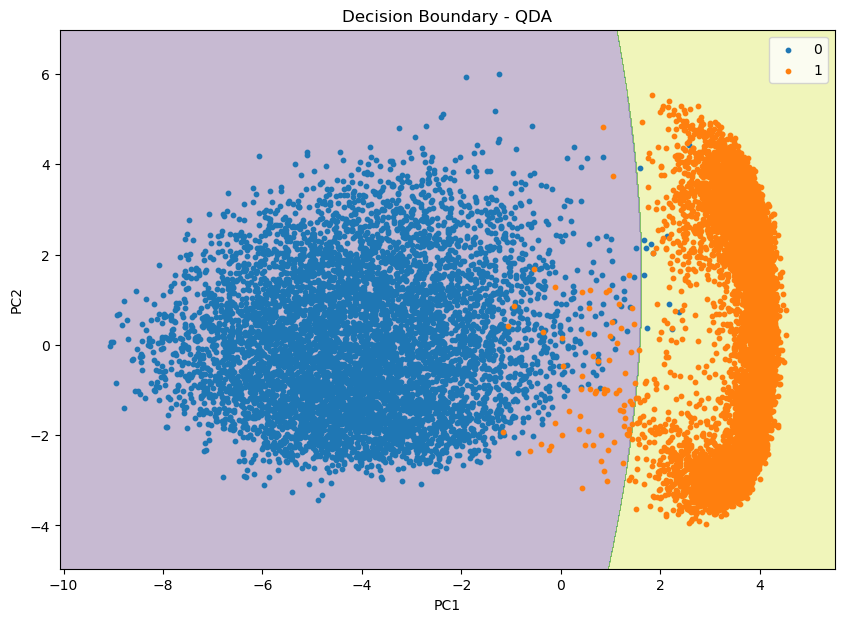

In [2]:
h=0.02

x_min,x_max=X_pca[:,0].min()-1,X_pca[:,0].max()+1
y_min,y_max=X_pca[:,1].min()-1,X_pca[:,1].max()+1

xx,yy=np.meshgrid(
    np.arange(x_min,x_max,h),
    np.arange(y_min,y_max,h)
)

Z=qda.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)

plt.figure(figsize=(10,7))

plt.contourf(xx,yy,Z,alpha=0.3)

plt.scatter(
    X_pca[y==0,0],
    X_pca[y==0,1],
    label="0",
    s=10
)

plt.scatter(
    X_pca[y==1,0],
    X_pca[y==1,1],
    label="1",
    s=10
)

plt.title("Decision Boundary - QDA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.show()